In [1]:
# example for accessing smeared hits and fitted tracks
import math
import os
import sys
sys.path.append('/afs/cern.ch/work/m/maborisy/FairShip/python/')
import ROOT
import ctypes
import rootUtils as ut
import shipunit as u
from ShipGeoConfig import ConfigRegistry
from rootpyPickler import Unpickler
from decorators import *
import shipRoot_conf
from argparse import ArgumentParser


ROOT.gStyle.SetOptFit(0);

shipRoot_conf.configure()
pdgDB = ROOT.TDatabasePDG.Instance()
PDG = ROOT.TDatabasePDG.Instance()

chi2CutOff  = 4.
fiducialCut = False
measCutFK = 25
measCutPR = 22
docaCut = 2.

inputFile = '/afs/cern.ch/work/m/maborisy/short/ship.conical.Pythia8-TGeant4_rec.root'

HNL_code = 9900015

geoFile = None

if not inputFile.find(',')<0 :
  sTree = ROOT.TChain("cbmsim")
  for x in inputFile.split(','):
    sTree.AddFile(x)
else:
  f = ROOT.TFile(inputFile)
  sTree = f.cbmsim

# try to figure out which ecal geo to load
if not geoFile:
    geoFile = inputFile.replace('ship.','geofile_full.').replace('_rec.','.')

fgeo = ROOT.TFile(geoFile)

# new geofile, load Shipgeo dictionary written by run_simScript.py
upkl    = Unpickler(fgeo)
ShipGeo = upkl.load('ShipGeo')
ecalGeoFile = ShipGeo.ecal.File
dy = ShipGeo.Yheight/u.m

# -----Create geometry----------------------------------------------
import shipDet_conf
run = ROOT.FairRunSim()
run.SetName("TGeant4")  # Transport engine
run.SetSink(ROOT.FairRootFileSink(ROOT.TMemFile('output', 'recreate')))  # Dummy output file
run.SetUserConfig("g4Config_basic.C") # geant4 transport not used, only needed for the mag field
rtdb = run.GetRuntimeDb()
# -----Create geometry----------------------------------------------
modules = shipDet_conf.configure(run,ShipGeo)

import geomGeant4
if hasattr(ShipGeo.Bfield,"fieldMap"):
  fieldMaker = geomGeant4.addVMCFields(ShipGeo, '', True, withVirtualMC = False)
else:
  print("no fieldmap given, geofile too old, not anymore support")
  exit(-1)
sGeo   = fgeo.FAIRGeom
geoMat =  ROOT.genfit.TGeoMaterialInterface()
ROOT.genfit.MaterialEffects.getInstance().init(geoMat)
bfield = ROOT.genfit.FairShipFields()
bfield.setField(fieldMaker.getGlobalField())
fM = ROOT.genfit.FieldManager.getInstance()
fM.init(bfield)

volDict = {}
i=0
for x in ROOT.gGeoManager.GetListOfVolumes():
  volDict[i]=x.GetName()
  i+=1

# prepare veto decisions
import shipVeto
veto = shipVeto.Task(sTree)

Welcome to JupyROOT 6.30/08
Calling addVMCFields


In [2]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

color1 = ROOT.TColor.GetFreeColorIndex()
ROOT.TColor(color1, 63, 144, 218)

color2 = ROOT.TColor.GetFreeColorIndex()
ROOT.TColor(color2, 231, 99, 0)

In [3]:
#f = ROOT.TFile('/afs/cern.ch/work/m/maborisy/short/ship.conical.Pythia8-TGeant4_rec.root')
# f = ROOT.TFile('/afs/cern.ch/work/m/maborisy/field_local/m0.25-i0/ship.conical.Pythia8-TGeant4_rec.root')
# sTree = f.Get('cbmsim')

In [4]:
import glob
path = '/afs/cern.ch/work/m/maborisy/'

#for m in ['0.25', '0.5', '1.0', '2.0', '4.0', '8.0']:
HNL_mass = '0.25'
files = glob.glob(f'{path}/m{HNL_mass}*/*_rec.root')

In [5]:
from array import array
def dist2InnerWall(X,Y,Z):
  dist = 0
 # return distance to inner wall perpendicular to z-axis, if outside decayVolume return 0.
  node = sGeo.FindNode(X,Y,Z)
  if ShipGeo.tankDesign < 5:
     if not 'cave' in node.GetName(): return dist  # TP
  else:
     if not 'DecayVacuum' in node.GetName(): return dist
  start = array('d',[X,Y,Z])
  nsteps = 8
  dalpha = 2*ROOT.TMath.Pi()/nsteps
  rsq = X**2+Y**2
  minDistance = 100 *u.m
  for n in range(nsteps):
    alpha = n * dalpha
    sdir  = array('d',[ROOT.TMath.Sin(alpha),ROOT.TMath.Cos(alpha),0.])
    node = sGeo.InitTrack(start, sdir)
    nxt = sGeo.FindNextBoundary()
    if ShipGeo.tankDesign < 5 and nxt.GetName().find('I')<0: return 0
    distance = sGeo.GetStep()
    if distance < minDistance  : minDistance = distance
  return minDistance

def isInFiducial(X,Y,Z):
   if not fiducialCut: return True
   if Z > ShipGeo.TrackStation1.z : return False
   if Z < ShipGeo.vetoStation.z+100.*u.cm : return False
   # typical x,y Vx resolution for exclusive HNL decays 0.3cm,0.15cm (gaussian width)
   if dist2InnerWall(X,Y,Z)<5*u.cm: return False
   return True
#
def ImpactParameter(point,tPos,tMom):
  t = 0
  if hasattr(tMom,'P'): P = tMom.P()
  else:                 P = tMom.Mag()
  for i in range(3):   t += tMom(i)/P*(point(i)-tPos(i))
  dist = 0
  for i in range(3):   dist += (point(i)-tPos(i)-t*tMom(i)/P)**2
  dist = ROOT.TMath.Sqrt(dist)
  return dist
#
def checkHNLorigin(sTree):
 flag = True
 if not fiducialCut: return flag
 flag = False
# only makes sense for signal == HNL
 hnlkey = -1
 for n in range(sTree.MCTrack.GetEntries()):
   mo = sTree.MCTrack[n].GetMotherId()
   if mo <0: continue
   if abs(sTree.MCTrack[mo].GetPdgCode()) == 9900015:
       hnlkey = n
       break
 if hnlkey<0 :
  ut.reportError("ShipAna: checkHNLorigin, no HNL found")
 else:
  # MCTrack after HNL should be first daughter
  theHNLVx = sTree.MCTrack[hnlkey]
  X,Y,Z =  theHNLVx.GetStartX(),theHNLVx.GetStartY(),theHNLVx.GetStartZ()
  if isInFiducial(X,Y,Z): flag = True
 return flag

def checkFiducialVolume(sTree,tkey,dy):
# extrapolate track to middle of magnet and check if in decay volume
   inside = True
   if not fiducialCut: return True
   fT = sTree.FitTracks[tkey]
   rc,pos,mom = TrackExtrapolateTool.extrapolateToPlane(fT,ShipGeo.Bfield.z)
   if not rc: return False
   if not dist2InnerWall(pos.X(),pos.Y(),pos.Z())>0: return False
   return inside
def getPtruthFirst(sTree,mcPartKey):
   Ptruth,Ptruthx,Ptruthy,Ptruthz = -1.,-1.,-1.,-1.
   for ahit in sTree.strawtubesPoint:
     if ahit.GetTrackID() == mcPartKey:
        Ptruthx,Ptruthy,Ptruthz = ahit.GetPx(),ahit.GetPy(),ahit.GetPz()
        Ptruth  = ROOT.TMath.Sqrt(Ptruthx**2+Ptruthy**2+Ptruthz**2)
        break
   return Ptruth,Ptruthx,Ptruthy,Ptruthz

def access2SmearedHits():
 key = 0
 for ahit in ev.SmearedHits.GetObject():
   print(ahit[0],ahit[1],ahit[2],ahit[3],ahit[4],ahit[5],ahit[6])
   # follow link to true MCHit
   mchit   = TrackingHits[key]
   mctrack =  MCTracks[mchit.GetTrackID()]
   print(mchit.GetZ(),mctrack.GetP(),mctrack.GetPdgCode())
   key+=1

def match2HNL(sTree, p):
    matched = False
    hnlKey  = []
    for t in [p.GetDaughter(0),p.GetDaughter(1)]:
      mcp = sTree.fitTrack2MC[t]
      while mcp > -0.5:
        mo = sTree.MCTrack[mcp]
        if abs(mo.GetPdgCode()) == 9900015:
           hnlKey.append(mcp)
           break
        mcp = mo.GetMotherId()
    if len(hnlKey) == 2:
       if hnlKey[0] == hnlKey[1]:
        return hnlKey[0]
    return None

In [6]:
f = ROOT.TFile('/afs/cern.ch/work/m/maborisy/short/ship.conical.Pythia8-TGeant4_rec.root')
sTree = f.Get('cbmsim')

print(sTree)

if sTree.GetBranch("FitTracks_PR"): sTree.FitTracks = sTree.FitTracks_PR
measCut = measCutPR
if sTree.GetBranch("fitTrack2MC_PR"):  sTree.fitTrack2MC = sTree.fitTrack2MC_PR
if sTree.GetBranch("Particles_PR"):    sTree.Particles   = sTree.Particles_PR

count = 0
    
for k in range(sTree.GetEntries()):
    sTree.GetEntry(k)

    for HNL in sTree.Particles:
        t1,t2 = HNL.GetDaughter(0),HNL.GetDaughter(1)
    # kill tracks outside fiducial volume, if enabled
        if not checkFiducialVolume(sTree,t1,dy) or not checkFiducialVolume(sTree,t2,dy) : continue
        checkMeasurements = True
    # cut on nDOF
        for tr in [t1,t2]:
          fitStatus  = sTree.FitTracks[tr].getFitStatus()
          nmeas = fitStatus.getNdf()
          if nmeas < measCut: checkMeasurements = False
        if not checkMeasurements: continue
    # check mc matching
        matched = match2HNL(sTree, HNL)
        
        if matched is None:
            continue
        
        print(matched)
        
        HNLPos = ROOT.TLorentzVector()
        HNL.ProductionVertex(HNLPos)
        HNLMom = ROOT.TLorentzVector()
        HNL.Momentum(HNLMom)
        doca  =  HNL.GetDoca()
        count += 1

Name: cbmsim Title: /cbmroot_0
2
2
2
2
2
2
2
2
2
2
2
2
2


In [7]:
9900015

9900015

In [8]:
HNLMom.M()

0.27134530253393735

In [9]:
#sTree = ROOT.TChain("cbmsim")
import math
def get_errors(files):
    errors = {
        'm': list(),
        'pz': list(),
        'pt': list(),
        'px': list(),
        'py': list(),
        'p': list(),
        'dp_over_p': list(),
        'ip': list()
    }
    
    origin = ROOT.TVector3(0, 0, ShipGeo.target.z0)

    for file in files:
        f = ROOT.TFile(file)
        sTree = f.Get('cbmsim')

        print(sTree)
        
        if sTree.GetBranch("FitTracks_PR"):
            sTree.FitTracks = sTree.FitTracks_PR
        measCut = measCutPR
        if sTree.GetBranch("fitTrack2MC_PR"):
            sTree.fitTrack2MC = sTree.fitTrack2MC_PR
        if sTree.GetBranch("Particles_PR"):
            sTree.Particles   = sTree.Particles_PR

        for k in range(sTree.GetEntries()):
            sTree.GetEntry(k)

            for HNL in sTree.Particles:
                t1,t2 = HNL.GetDaughter(0), HNL.GetDaughter(1)
            # kill tracks outside fiducial volume, if enabled
                if not checkFiducialVolume(sTree,t1,dy) or not checkFiducialVolume(sTree,t2,dy) : continue
                checkMeasurements = True
            # cut on nDOF
                for tr in [t1,t2]:
                    fitStatus  = sTree.FitTracks[tr].getFitStatus()
                    nmeas = fitStatus.getNdf()
                    if nmeas < measCut: checkMeasurements = False
                if not checkMeasurements:
                    continue
            # check mc matching
                matched = match2HNL(sTree, HNL)
                if matched is None:
                    continue

                HNLPos = ROOT.TLorentzVector()
                HNL.ProductionVertex(HNLPos)
                
                if not isInFiducial(HNLPos.X(),HNLPos.Y(),HNLPos.Z()):
                    continue
                
                HNLMom = ROOT.TLorentzVector()
                HNL.Momentum(HNLMom)
                px, py, pz = HNLMom.Px(), HNLMom.Py(), HNLMom.Pz()
                p = math.sqrt(px ** 2 + py ** 2 + pz ** 2)
                doca  =  HNL.GetDoca()
                
                true_mass = sTree.MCTrack[matched].GetMass()
                true_p = ROOT.TVector3()
                sTree.MCTrack[matched].GetMomentum(true_p)
                tx, ty, tz = true_p
                true_p = math.sqrt(tx ** 2 + ty ** 2 + tz ** 2)
                
                dist = ImpactParameter(origin, HNLPos, HNLMom)
                
#                 if name not in errors['m']:
#                     for key in errors:
#                         errors[key][name] = list()
                
                errors['m'].append((p, (HNLMom.M() - true_mass) / u.MeV ))
                errors['pt'].append((true_p, math.sqrt((px - tx) ** 2 + (py - ty) ** 2)))
                errors['px'].append((true_p, px - tx))
                errors['py'].append((true_p, py - ty))
                errors['pz'].append((true_p, pz - tz))
                errors['p'].append((true_p, p - true_p))
                errors['dp_over_p'].append((true_p, (p - true_p) / true_p))
                errors['ip'].append((true_p, dist))
                
    return errors

In [10]:
errors_new = get_errors(
    glob.glob(f'{path}/field_local/m{HNL_mass}*/*_rec.root')[:10]
)

errors_old = get_errors(
    glob.glob(f'{path}/field_local_old/m{HNL_mass}*/*_rec.root')[:10]
)

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0


In [11]:
def ImpactParameter(point,tPos,tMom):
  t = 0
  if hasattr(tMom,'P'): P = tMom.P()
  else:                 P = tMom.Mag()
  for i in range(3):   t += tMom(i)/P*(point(i)-tPos(i))
  dist = 0
  for i in range(3):   dist += (point(i)-tPos(i)-t*tMom(i)/P)**2
  dist = ROOT.TMath.Sqrt(dist)
  return dist

In [12]:
dy = ShipGeo.Yheight/u.m

def impact(origin, pos, mom):
  t = 0
  if hasattr(tMom,'P'): P = tMom.P()
  else:                 P = tMom.Mag()
  for i in range(3):   t += tMom(i)/P*(point(i)-tPos(i))
  dist = 0
  for i in range(3):   dist += (point(i)-tPos(i)-t*tMom(i)/P)**2
  dist = ROOT.TMath.Sqrt(dist)
  return dist

def get_impact(files):
    impact = dict()

    for file in files:
        f = ROOT.TFile(file)
        sTree = f.Get('cbmsim')

        if sTree.GetBranch("FitTracks_PR"): sTree.FitTracks = sTree.FitTracks_PR
        measCut = measCutPR
        if sTree.GetBranch("fitTrack2MC_PR"):  sTree.fitTrack2MC = sTree.fitTrack2MC_PR
        if sTree.GetBranch("Particles_PR"):    sTree.Particles   = sTree.Particles_PR

        for k in range(sTree.GetEntries()):
            sTree.GetEntry(k)
            
            for i in range(sTree.FitTracks.GetEntries()):
                j = sTree.fitTrack2MC[i]
                
                
                state = sTree.FitTracks[i].getFittedState()
                
                
    return impact

In [13]:
def fitSingleGauss(h, name, color):
    ba = h.GetBinCenter(1)
    be = h.GetBinCenter(h.GetNbinsX())
    
    bw    = h.GetBinWidth(1)
    mean  = h.GetMean()
    sigma = h.GetRMS()
    norm  = h.GetEntries()*0.3
    myGauss = ROOT.TF1(name,'[0]*'+str(bw)+'/([2]*sqrt(2*pi))*exp(-0.5*((x-[1])/[2])**2)+[3]',4)
    myGauss.SetLineColor(color)
    myGauss.SetParameter(0,norm)
    myGauss.SetParameter(1,mean)
    myGauss.SetParameter(2,sigma)
    myGauss.SetParameter(3,1.)
    myGauss.SetParName(0, f'Signal {name}')
    myGauss.SetParName(1, f'Mean {name}')
    myGauss.SetParName(2, f'Sigma {name}')
    myGauss.SetParName(3, f'bckgr {name}')


    print(myGauss.GetParameter(0))


    h.Fit(myGauss,'','',ba,be)
    
    return myGauss

In [14]:
def make_momentum_plots(errors_old, errors_new, axis, file, low, high, HNL_mass):
    result = []

    groups = [
        ('mu', ['mu-'], '#mu^{-}'),
        ('anti-mu', ['mu+'], '#mu^{+}'),
        ('muon', ['mu-', 'mu+'], '#mu'),
        
        ('pi', ['pi-'], '#pi^{-}'),
        ('anti-pi', ['pi+'], '#pi^{+}'),
        ('pi0', ['pi0'], '#pi^{0}'),
        ('pion', ['pi-', 'pi+', 'pi0'], '#pi'),
    ]
    
    for fname, pts, name in groups:
        canvas = ROOT.TCanvas(f"momentum resolution {fname}", "Histograms on Same Canvas", 800, 600)
        
        key_old = f'{axis}-momentum resolution {fname} old'
        h_old = ROOT.TH1F(
            key_old, f'{axis}-momentum resolution {name}, HNL = {HNL_mass} GeV / c^{{2}};momentum error;prob',
            50, low, high
        )
        
        key_new = f'{axis}-momentum resolution {fname} new'
        h_new = ROOT.TH1F(
            key_new, f'{axis}-momentum resolution {name}, HNL = {HNL_mass} GeV / c^{{2}};momentum error;prob',
            50, low, high
        )
        
        h = {key_old: h_old, key_new: h_new}

        for pt in pts:
            if pt in errors_old:
                for x in errors_old[pt]:
                    h_old.Fill(x)
        for pt in pts:
            if pt in errors_new:
                for x in errors_new[pt]:
                    h_new.Fill(x)
        
        h_old.SetLineColor(ROOT.kBlue)
        h_new.SetLineColor(ROOT.kRed)
        h_old.DrawNormalized()
        h_new.DrawNormalized('SAME')
        # fitSingleGauss(h, key)
        
        
        
        # Create a legend
        legend = ROOT.TLegend(0.75, 0.65, 0.9, 0.75)
        legend.AddEntry(h1, "Old field", "l")
        legend.AddEntry(h2, "New field", "l")
        legend.Draw()
        
        canvas.Draw()
        
        canvas.SaveAs(file.format(fname=fname))
        result.append(file.format(fname=fname))
    return result

In [107]:
def make_plots(errors_old, errors_new, file, low, high, HNL_mass, title, quantity, std=True):
    result = []

    groups = [
        ('mu', ['mu-'], '#mu^{-}'),
        ('anti-mu', ['mu+'], '#mu^{+}'),
        ('muon', ['mu-', 'mu+'], '#mu'),
        
        ('pi', ['pi-'], '#pi^{-}'),
        ('anti-pi', ['pi+'], '#pi^{+}'),
        ('pi0', ['pi0'], '#pi^{0}'),
        ('pion', ['pi-', 'pi+', 'pi0'], '#pi'),
    ]
#     for fname, pts, name in groups:
    fname = 'HNL'
    name = 'HNL'
    canvas = ROOT.TCanvas(f"{quantity} {fname}", "Histograms on Same Canvas", 800, 600)

    h_old = ROOT.TH1F(
        f'{quantity}, old field', f'{title}, HNL = {HNL_mass} GeV / c^{{2}};{quantity};prob',
        35, low, high
    )

    h_new = ROOT.TH1F(
        f'{quantity}, new field', f'{title}, HNL = {HNL_mass} GeV / c^{{2}};{quantity};prob',
        35, low, high
    )

    xs_old = list()
#     for pt in pts:
#         if pt in errors_old:
    for tp, x in errors_old:
        h_old.Fill(x)
        xs_old.append(x)
    h_old.SetLineColor(ROOT.kBlue)
    if std:
        fit_old = fitSingleGauss(h_old, '1', ROOT.kBlue)

    xs_new = list()
#     for pt in pts:
#         if pt in errors_new:
    for tp, x in errors_new:
        h_new.Fill(x)
        xs_new.append(x)
    h_new.SetLineColor(ROOT.kRed)
    if std:
        fit_new = fitSingleGauss(h_new, '2', ROOT.kRed)

    h_old.Draw()
    h_new.Draw('SAME')
    
    if std:
        fit_old.Draw('same')
        fit_new.Draw('same')
    
        infoBox = ROOT.TPaveText(0.7, 0.55, 1.0, 0.75, "NDC");

        infoBox.SetFillColor(0);
        infoBox.SetTextSize(0.03);
        infoBox.SetTextFont(22);
        infoBox.SetBorderSize(1);

        infoBox.AddText("Gaussian fit:");
        infoBox.AddText(f"#mu_{{old}}={fit_old.GetParameter(1):.2e} #pm {fit_old.GetParError(1):.2e}")
        infoBox.AddText(f"#sigma_{{old}}={fit_old.GetParameter(2):.2e} #pm {fit_old.GetParError(2):.2e}")
        infoBox.AddText(f"#mu_{{new}}={fit_new.GetParameter(1):.2e} #pm {fit_new.GetParError(1):.2e}")
        infoBox.AddText(f"#sigma_{{new}}={fit_new.GetParameter(2):.2e} #pm {fit_new.GetParError(2):.2e}")

        infoBox.Draw('same')

    # Create a legend
    import numpy as np
    mean_old, mean_new = np.mean(xs_old), np.mean(xs_new)
    std_old, std_new = np.std(xs_old, ddof=1), np.std(xs_new, ddof=1)
    error_mean_old = std_old / np.sqrt(len(xs_old) - 1)
    error_mean_new = std_new / np.sqrt(len(xs_new) - 1)
    error_std_old = std_old / np.sqrt(2) / np.sqrt(len(xs_old) - 1)
    error_std_new = std_new / np.sqrt(2) / np.sqrt(len(xs_new) - 1)
    legend = ROOT.TLegend(0.8, 0.45, 1.0, 0.55)
    legend.SetFillColor(0);
    legend.SetTextSize(0.03);
    legend.SetTextFont(22);
    legend.SetBorderSize(1);
    legend.AddEntry(h_old, f"Old field", "l")
    legend.AddEntry(h_new, f"New field", "l")
    legend.Draw()

    canvas.Draw()
    canvas.SaveAs(file.format(fname=fname))
    result.append(file.format(fname=fname))
    return result

63.599999999999994
56.699999999999996


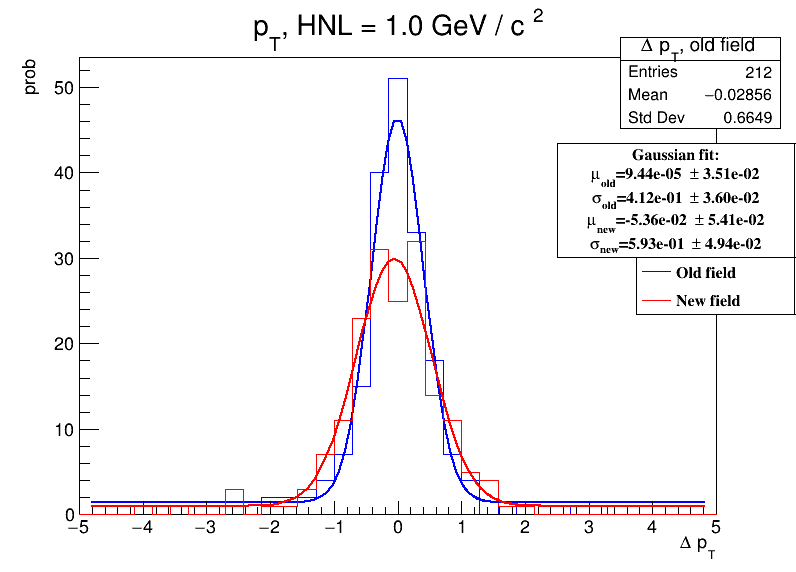

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =       4.5085
NDf                       =           12
Edm                       =  1.10162e-05
NCalls                    =          150
Signal 1                  =      162.276   +/-   13.6632     
Mean 1                    =  9.43863e-05   +/-   0.0350881   
Sigma 1                   =     0.411798   +/-   0.0359516   
bckgr 1                   =      1.39662   +/-   0.424766    
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =       6.6371
NDf                       =           14
Edm                       =  2.38658e-08
NCalls                    =          114
Signal 2                  =      150.245   +/-   13.9561     
Mean 2                    =   -0.0536017   +/-   0.0540812   
Sigma 2                   =     0.592675   +/-   0.0494435   
bckgr 2                   =      1.00867   +/-   0.438453    


Info in <TCanvas::Print>: png file test.png has been created


In [108]:
from IPython.display import Image

files = make_plots(
    errors_old['m'], errors_new['m'], 'test.png', -5, 5.00, HNL_mass, std=True,
    title='p_{T}', quantity='#Delta p_{T}'
)
for file in files:
    display(Image(filename=file))

In [109]:
def make_2D_plots(errors, file, low_p, high_p, low_y, high_y, HNL_mass, title, quantity, std=True):
    result = []

    groups = [
        ('mu', ['mu-'], '#mu^{-}'),
        ('anti-mu', ['mu+'], '#mu^{+}'),
        ('muon', ['mu-', 'mu+'], '#mu'),
        
        ('pi', ['pi-'], '#pi^{-}'),
        ('anti-pi', ['pi+'], '#pi^{+}'),
        ('pi0', ['pi0'], '#pi^{0}'),
        ('pion', ['pi-', 'pi+', 'pi0'], '#pi'),
    ]
    # for fname, pts, name in groups:
    canvas = ROOT.TCanvas(f"{quantity}", "Histograms on Same Canvas", 800, 600)

    h = ROOT.TH2D(
        f'{quantity} old field', f'{title}, HNL = {HNL_mass} GeV / c^{{2}};true momentum;{quantity}',
        20, low_p, high_p, 20, low_y, high_y
    )

    for tp, x in errors:
        h.Fill(tp, x)

    h.Draw('COLORZ')

    canvas.Draw()
    canvas.SaveAs(file.format(fname=fname))
    result.append(file.format(fname=fname))
    return result

In [110]:
errors = dict()

for HNL_mass in ['0.25', '0.5', '1.0']:
    errors[HNL_mass] = dict()

    for B, results_dir in zip(['new', 'old'], ['field_local', 'field_local_old']):
        errors[HNL_mass][B] = \
            get_errors(
                glob.glob(f'{path}/{results_dir}/m{HNL_mass}*/*_rec.root')
            )

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cb

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cb

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cb

In [111]:
import numpy as np
def minmax(errors, q):
    xs = np.array([
        e for m in errors for B in errors[m] for _, e in errors[m][B][q]
    ])
    
    low, high = np.quantile(xs, q=(0.05, 0.95))
    
    delta = high - low
    
    left, right = max(low - 0.2 * delta, np.min(xs)), min(high + 0.2 * delta, np.max(xs))
    return left, right

In [112]:
bounds = dict()

for q in errors['0.25']['old']:
    bounds[q] = minmax(errors, q)

In [113]:
outdir = 'plots'
os.makedirs(outdir, exist_ok=True)

titles = {
    'm': 'Mass resolution',
    'p': 'Momentum',
    'px': 'p_{x}',
    'py': 'p_{y}',
    'pz': 'p_{z}',
    'pt': 'p_{T}',
    'ip': 'Impact parameter to origin',
    'dp_over_p': '#Delta p / p'
}

quantities = {
    'm': 'mass error [MeV]',
    'p': 'momentum error',
    'px': 'momentum error',
    'py': 'momentum error',
    'pz': 'momentum error',
    'pt': 'momentum error',
    'ip': 'Impact parameter [cm]',
    'dp_over_p': '#Delta p / p'
}

one_sided = {
    'm': False,
    'p': False,
    'px': False,
    'py': False,
    'pz': False,
    'pt': True,
    'ip': True,
    'dp_over_p': False
}

all_files = []

for HNL_mass, fname in zip(['0.25', '0.5', '1.0'], ['0250', '0500', '1000']):
    for q in errors[HNL_mass]['old']:
        print(HNL_mass, q)
        
        left, right = bounds[q]
        files = make_plots(
            errors[HNL_mass]['old'][q], errors[HNL_mass]['new'][q], f'{outdir}/m{fname}-{q}.png',
            left, right, HNL_mass,
            title=titles[q], quantity=quantities[q], std=not one_sided[q]
        )
        all_files.extend(files)

for HNL_mass, fname in zip(['0.25', '0.5', '1.0'], ['0250', '0500', '1000']):
    for B in ['old', 'new']:
        for q in errors[HNL_mass]['old']:
            left, right = bounds[q]
            files = make_2D_plots(
                errors[HNL_mass][B][q],
                f'{outdir}/m{fname}-{B}-{q}.png',
                0.0, max_p, left, right, HNL_mass,
                title=titles[q], quantity=quantities[q]
            )
            all_files.extend(files)

0.25 m
750.0
751.1999999999999
0.25 pz
750.0
751.1999999999999
0.25 pt
0.25 px
750.0
751.1999999999999
0.25 py
750.0
751.1999999999999
0.25 p
750.0
751.1999999999999
0.25 dp_over_p
750.0
751.1999999999999
0.25 ip
0.5 m
583.1999999999999
580.1999999999999
0.5 pz
583.1999999999999
580.1999999999999
0.5 pt
0.5 px
583.1999999999999
580.1999999999999
0.5 py
583.1999999999999
580.1999999999999
0.5 p
583.1999999999999
580.1999999999999
0.5 dp_over_p
583.1999999999999
580.1999999999999
0.5 ip
1.0 m
534.0
534.6
1.0 pz
534.0
534.6
1.0 pt
1.0 px
534.0
534.6
1.0 py
534.0
534.6
1.0 p
534.0
534.6
1.0 dp_over_p
534.0
534.6
1.0 ip
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      35.9074
NDf                       =           16
Edm                       =   1.3081e-06
NCalls                    =          182
Signal 1                  =      2263.91   +/-   47.8834     
Mean 1                    =   -0.0392597   +/-   0.0158736   
Sigma 1           

Info in <TCanvas::Print>: png file plots/m0250-m.png has been created
Info in <TCanvas::Print>: png file plots/m0250-pz.png has been created
Info in <TCanvas::Print>: png file plots/m0250-pt.png has been created
Info in <TCanvas::Print>: png file plots/m0250-px.png has been created
Info in <TCanvas::Print>: png file plots/m0250-py.png has been created
Info in <TCanvas::Print>: png file plots/m0250-p.png has been created
Info in <TCanvas::Print>: png file plots/m0250-dp_over_p.png has been created
Info in <TCanvas::Print>: png file plots/m0250-ip.png has been created
Info in <TCanvas::Print>: png file plots/m0500-m.png has been created
Info in <TCanvas::Print>: png file plots/m0500-pz.png has been created
Info in <TCanvas::Print>: png file plots/m0500-pt.png has been created
Info in <TCanvas::Print>: png file plots/m0500-px.png has been created
Info in <TCanvas::Print>: png file plots/m0500-py.png has been created
Info in <TCanvas::Print>: png file plots/m0500-p.png has been created
Inf

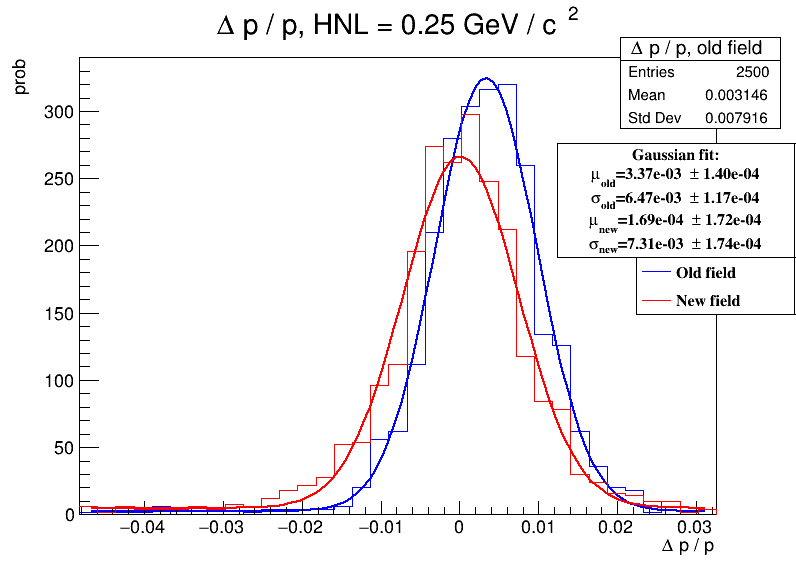

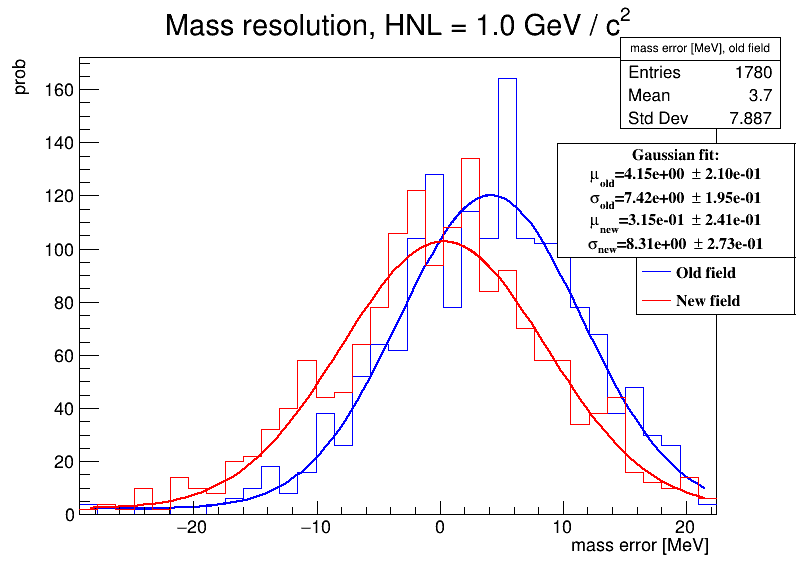

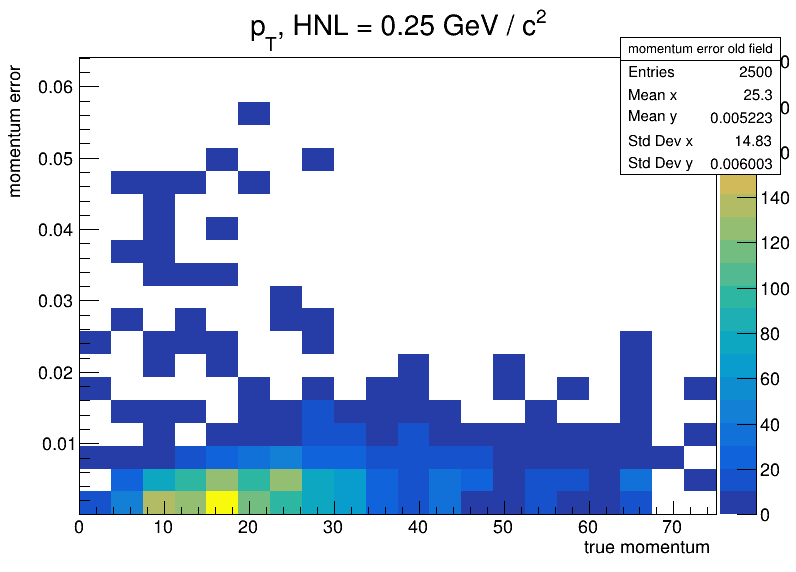

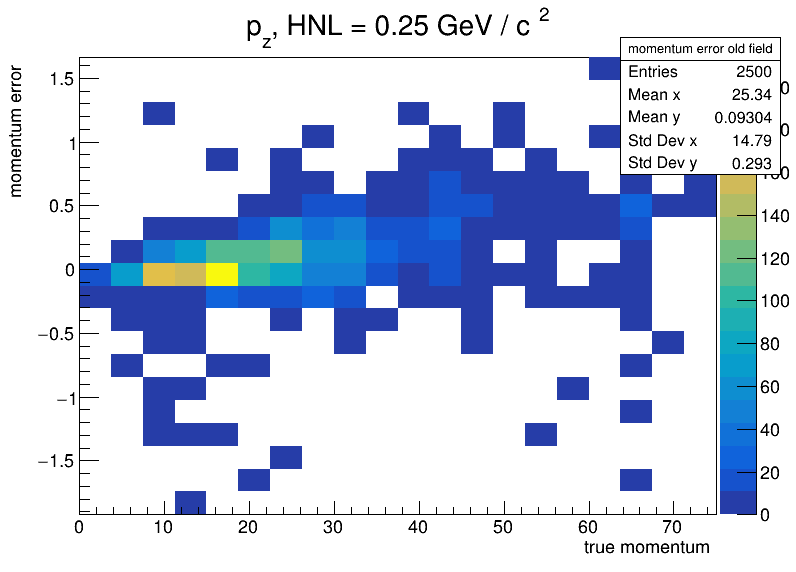

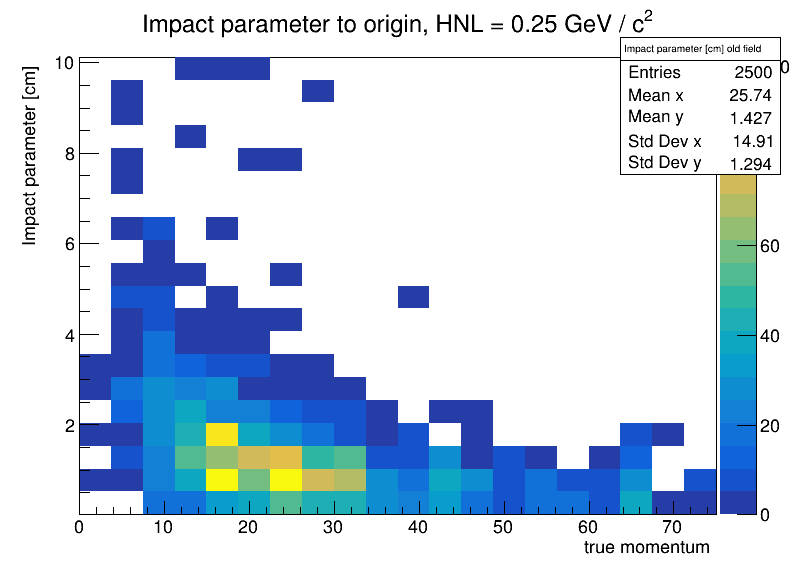

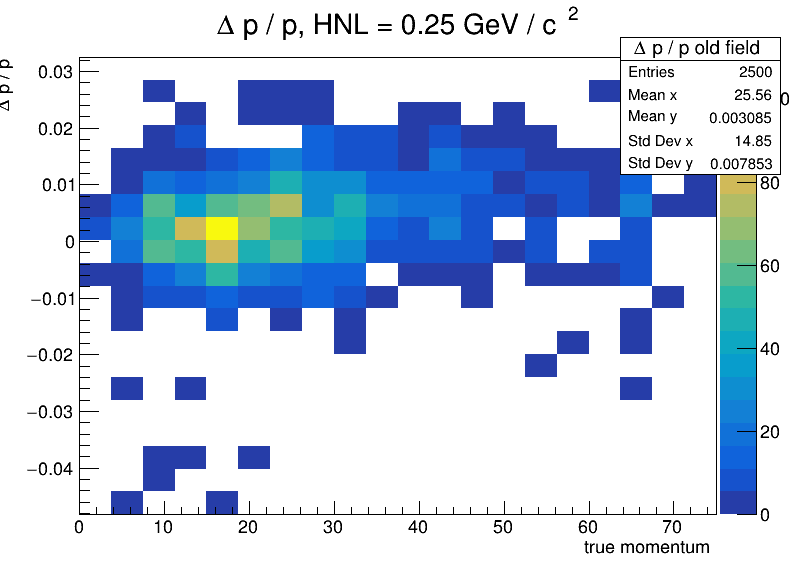

In [114]:
from IPython.display import Image

display(Image(filename="plots/m0250-dp_over_p.png"))

display(Image(filename="plots/m1000-m.png"))

display(Image(filename="plots/m0250-old-pt.png"))

display(Image(filename="plots/m0250-old-pz.png"))

display(Image(filename="plots/m0250-old-ip.png"))

display(Image(filename="plots/m0250-old-dp_over_p.png"))

In [104]:
def make_impact_plots(err_old, err_new, file, low, high, HNL_mass):
    result = []

    groups = [
        ('mu', ['mu-'], '#mu^{-}'),
        ('anti-mu', ['mu+'], '#mu^{+}'),
        ('muon', ['mu-', 'mu+'], '#mu'),
        
        ('pi', ['pi-'], '#pi^{-}'),
        ('anti-pi', ['pi+'], '#pi^{+}'),
        ('pi0', ['pi0'], '#pi^{0}'),
        ('pion', ['pi-', 'pi+', 'pi0'], '#pi'),
    ]
    for fname, pts, name in groups:
        h = dict()
        key = f'impact parameter {fname}'
        ut.bookHist(
            h, key, f'impact parameter to origin {name}, HNL = {HNL_mass} GeV / c^{{2}}',
            50, low, high
        )

        for pt in pts:
            if pt in errors:
                for x in errors[pt]:
                    h[key].Fill(x)

        # fitSingleGauss(h, f'impact parameter {fname}')

        canvas = ROOT.TCanvas()
        h[key].SetXTitle('impact parameter, cm')
        h[key].Draw()
        canvas.SaveAs(file.format(fname=fname))
        result.append(file.format(fname=fname))
    return result

In [ ]:
px_files = make_momentum_plots(px_errors, 'x', 'field-m025-px-{fname}.png')

from IPython.display import Image

for file in px_files:
    display(Image(filename=file))

In [ ]:
from IPython.display import Image

display(Image(filename="m025-mass-pi0.png"))

In [ ]:
h['mass resolution'].Save()

In [ ]:
errors = []

for k in range(sTree.GetEntries()):
    sTree.GetEntry(k)

    for i in range(sTree.FitTracks.GetEntries()):
        j = sTree.fitTrack2MC[i]

        momentum = ROOT.TVector3() 
        sTree.MCTrack[j].GetMomentum(momentum)
        tx, ty, tz = momentum
        true_mass = sTree.MCTrack[j].GetMass()

        pid = sTree.MCTrack[j].GetPdgCode()
        try:
            name = pdgDB.GetParticle(pid).GetName()
        except:
            print(pid)
            name = '(unknown)'

        state = sTree.FitTracks[i].getFittedState()
        x, y, z = state.getMom()
        mass = state.getMass()
        pid = state.getPDG()
        try:
            name = pdgDB.GetParticle(pid).GetName()
        except:
            print(pid)
            name = '(unknown)'

        mass_error = mass - true_mass
        # print(f'{name}: {mass_error} ({mass} / {true_mass})')
        errors.append(mass_error / u.GeV)

In [ ]:
for ahit in sTree.strawtubesPoint:
    Ptruthx,Ptruthy,Ptruthz = ahit.GetPx(),ahit.GetPy(),ahit.GetPz()
    print(Ptruthx,Ptruthy,Ptruthz)
    Ptruth  = ROOT.TMath.Sqrt(Ptruthx**2+Ptruthy**2+Ptruthz**2)

In [ ]:
u.m

In [ ]:
ahit

In [ ]:
for i in range(sTree.MCTrack.GetEntries()):
    mother_id = sTree.MCTrack[i].GetMotherId()
    pid = sTree.MCTrack[i].GetPdgCode()
    try:
        name = pdgDB.GetParticle(pid).GetName()
    except:
        name = '(unknown)'

    x, y, z = sTree.MCTrack[i].GetStartX(), sTree.MCTrack[i].GetStartY(), sTree.MCTrack[i].GetStartZ()

    inside = isInFiducial(x, y, z)

    print(f'Particle {i}, type: {name} ({pid}), mother: {mother_id}')

In [ ]:
# sTree.GetBranch('FitTracks_PR')

In [ ]:
momentum = ROOT.TVector3()
sTree.MCTrack[i].GetMomentum(momentum)

In [ ]:
pdgDB.GetParticle(pid)

In [ ]:
from array import array
def dist2InnerWall(X,Y,Z):
  dist = 0
 # return distance to inner wall perpendicular to z-axis, if outside decayVolume return 0.
  node = sGeo.FindNode(X,Y,Z)
  if ShipGeo.tankDesign < 5:
     if not 'cave' in node.GetName(): return dist  # TP
  else:
     if not 'DecayVacuum' in node.GetName(): return dist
  start = array('d',[X,Y,Z])
  nsteps = 8
  dalpha = 2*ROOT.TMath.Pi()/nsteps
  rsq = X**2+Y**2
  minDistance = 100 *u.m
  for n in range(nsteps):
    alpha = n * dalpha
    sdir  = array('d',[ROOT.TMath.Sin(alpha),ROOT.TMath.Cos(alpha),0.])
    node = sGeo.InitTrack(start, sdir)
    nxt = sGeo.FindNextBoundary()
    if ShipGeo.tankDesign < 5 and nxt.GetName().find('I')<0: return 0
    distance = sGeo.GetStep()
    if distance < minDistance  : minDistance = distance
  return minDistance

def isInFiducial(X,Y,Z):
   if not fiducialCut: return True
   if Z > ShipGeo.TrackStation1.z : return False
   if Z < ShipGeo.vetoStation.z+100.*u.cm : return False
   # typical x,y Vx resolution for exclusive HNL decays 0.3cm,0.15cm (gaussian width)
   if dist2InnerWall(X,Y,Z)<5*u.cm: return False
   return True

In [ ]:
track2MC = sTree.fitTrack2MC

In [ ]:
track2MC[0]

In [ ]:
for i in range(sTree.FitTracks.GetEntries()):
    j = track2MC[i]

    momentum = ROOT.TVector3() 
    sTree.MCTrack[j].GetMomentum(momentum)
    x, y, z = momentum
    m = sTree.MCTrack[j].GetMass()
    
    pid = sTree.MCTrack[j].GetPdgCode()
    try:
        name = pdgDB.GetParticle(pid).GetName()
    except:
        print(pid)
        name = '(unknown)'
    
    print(name, m)
    print(x, y, z)
    
    state = sTree.FitTracks[i].getFittedState()
    x, y, z = state.getMom()
    m = state.getMass()
    pid = state.getPDG()
    try:
        name = pdgDB.GetParticle(pid).GetName()
    except:
        print(pid)
        name = '(unknown)'
    
    print(name, m)
    print(x, y, z)
    
    print()

In [ ]:
dir(state)

In [ ]:
import subprocess as sp

with open('event.dot', 'w') as g:
    g.write('digraph G {\n rankdir=LR;\n')

    for i in range(sTree.MCTrack.GetEntries()):
        mother_id = sTree.MCTrack[i].GetMotherId()
        pid = sTree.MCTrack[i].GetPdgCode()
        try:
            name = pdgDB.GetParticle(pid).GetName()
        except:
            print(pid)
            name = '(unknown)'
        
        x, y, z = sTree.MCTrack[i].GetStartX(), sTree.MCTrack[i].GetStartY(), sTree.MCTrack[i].GetStartZ()
        
        inside = isInFiducial(x, y, z)

        # print(f'Particle {i}, type: {name} ({pid}), mother: {mother_id}')
        if inside:
            g.write(f'p_{i}[label="{name}", style=filled, fillcolor=red]')
        else:
            g.write(f'p_{i}[label="{name}"];\n')
        g.write(f'p_{mother_id} -> p_{i};\n')
    
    g.write('}')

p = sp.run(['dot', 'event.dot', '-Tpng'], capture_output=True, text=False)
with open('event.png', 'wb') as g:
    g.write(p.stdout)
from IPython.display import Image

display(Image(filename="event.png"))

In [ ]:
if sTree.GetBranch("FitTracks_PR"):
    sTree.FitTracks = sTree.FitTracks_PR
measCut = measCutPR
if sTree.GetBranch("fitTrack2MC_PR"):  sTree.fitTrack2MC = sTree.fitTrack2MC_PR
if sTree.GetBranch("Particles_PR"):    sTree.Particles   = sTree.Particles_PR
# if not checkHNLorigin(sTree): pass
if not sTree.MCTrack.GetEntries()>1: wg = 1.
else:   wg = sTree.MCTrack[1].GetWeight()
if not wg>0.: wg=1.

In [ ]:
def print_tree_structure(tree, prefix=""):
    """ Recursively prints the TTree structure in a hierarchical way """
    for branch in tree.GetListOfBranches():
        print(f"{prefix}├── {branch.GetName()} ({branch.GetClassName()})")
        print_tree_structure(branch, prefix + "│   ")

In [ ]:
sTree.strawtubesPoint.GetEvent(0)

In [ ]:
for p in sTree.strawtubesPoint:
    try:
        p.GetEntry(0)
        print(p.fDetectorID)
    except:
        pass

In [ ]:
import subprocess as sp

def save_histograms_as_images(input_file, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    f_in = ROOT.TFile.Open(input_file, "READ")
    
    if not f_in or f_in.IsZombie():
        print("Error: Unable to open file!")
        return

    count = 0
    for key in f_in.GetListOfKeys():
        obj = key.ReadObj()
        if isinstance(obj, ROOT.TH1):  # Check if object is a histogram
            count += 1
            c1 = ROOT.TCanvas("c1", "Canvas")
            obj.Draw()
            hist_name = obj.GetName()
            hist_title = obj.GetTitle()

            # Replace spaces or special characters in the name to create valid filenames
            hist_name = hist_name.replace(" ", "_").replace("/", "_").replace("\\", "_")
            
            output_file = os.path.join(output_dir, f"{hist_name}.png")
            c1.SaveAs(output_file)  # Save as PNG
            del c1

    f_in.Close()
    print(f"{count} histograms saved as images in {output_dir}")
    
    direc = os.path.dirname(input_file)
    
    for item in glob.glob(f'{direc}/*.gif'):
        item = os.path.basename(item)
        print(os.path.join(direc, item), os.path.join(output_dir, item))
        sp.run(['cp', os.path.join(direc, item), os.path.join(output_dir, item)])

In [ ]:
!mkdir -p hist-new-0250/
!mkdir -p hist-new-0500/
!mkdir -p hist-new-1000/

In [ ]:
save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local/m0.25/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-new-0250/"
)

save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local/m0.5/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-new-0500/"
)

save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local/m1.0/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-new-1000/"
)

In [ ]:
save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local_old/m0.25/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-old-0250/"
)

save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local_old/m0.5/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-old-0500/"
)

save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local_old/m1.0/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-old-1000/"
)

In [ ]:
sTree.strawtubesPoint.At(0)

In [ ]:
branch = sTree.GetBranch('strawtubesPoint.fDetectorID')
# for branch in branch.GetListOfBranches():
#     if branch.GetName() == 'strawtubesPoint.fDetectorID':
#         break

In [ ]:
branch.Print()

In [ ]:
print_tree_structure(sTree)

In [ ]:
sTree.GetEvent(0)
v = sTree.FitTracks

In [ ]:
v.ls()

In [ ]:
particles = sTree.GetBranch('Particles')

In [ ]:
particles.GetListOfBranches().Print()

In [ ]:
particles.GetEntry(0)